In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

In [54]:
compas_two = pd.read_csv("compas-analysis-master/compas-scores-two-years.csv")
compas_two.head(5)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [55]:
compas_two.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

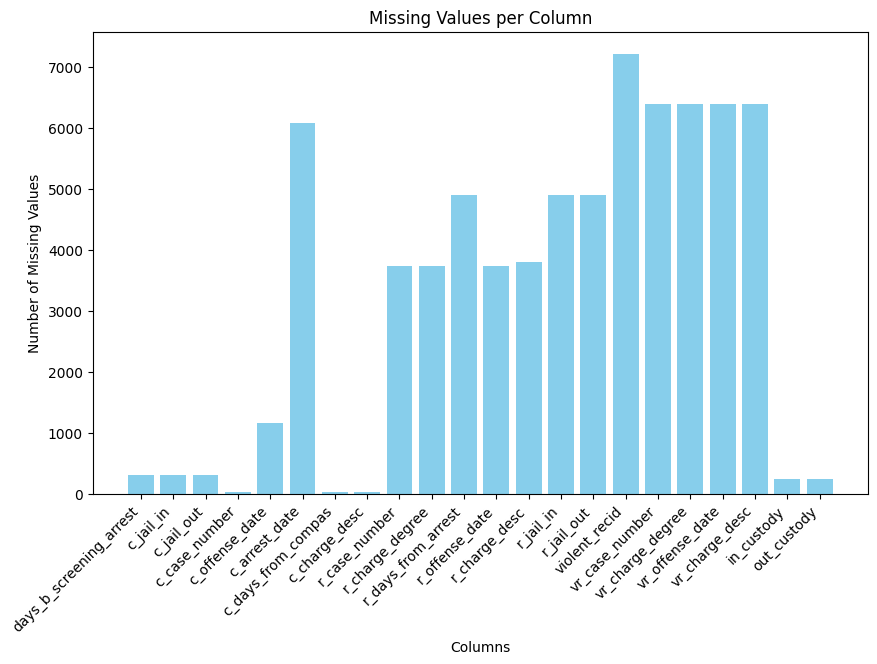

Columns with no missing values:
id
name
first
last
compas_screening_date
sex
dob
age
age_cat
race
juv_fel_count
decile_score
juv_misd_count
juv_other_count
priors_count
c_charge_degree
is_recid
is_violent_recid
type_of_assessment
decile_score.1
score_text
screening_date
v_type_of_assessment
v_decile_score
v_score_text
v_screening_date
priors_count.1
start
end
event
two_year_recid


In [56]:
missing_count = []
full_cols = []
missing_cols = []
for col in compas_two.columns:
    if compas_two[col].isna().sum() == 0:
        full_cols.append(col)
    else:
        missing_cols.append(col)
        missing_count.append(compas_two[col].isna().sum())

plt.figure(figsize=(10, 6))
plt.bar(missing_cols, missing_count, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Missing Values')
plt.xlabel("Columns")
plt.title('Missing Values per Column')
plt.show()
print("Columns with no missing values:")
for col in full_cols:
    print(col)

In [57]:
compas_two = compas_two.drop("violent_recid",axis=1)

In [58]:
numeric_cols = compas_two.select_dtypes(include=['float64', 'int64']).columns
for col in compas_two.columns:
    if col in numeric_cols:
        compas_two[col] = compas_two[col].fillna(compas_two[col].mean())
    else:
        compas_two[col] = compas_two[col].fillna(compas_two[col].mode()[0])
print("Missing values left:",compas_two.isna().sum().sum())

Missing values left: 0


In [59]:
compas_two['dob'] = pd.to_datetime(cox_parsed['dob'], dayfirst=True, errors='coerce')
compas_two['c_jail_in'] = pd.to_datetime(cox_parsed['c_jail_in'], dayfirst=True, errors='coerce')
compas_two['c_jail_out'] = pd.to_datetime(cox_parsed['c_jail_out'], dayfirst=True, errors='coerce')
compas_two['compas_screening_date'] = pd.to_datetime(cox_parsed['compas_screening_date'], dayfirst=True, errors='coerce')
compas_two['screening_date'] = pd.to_datetime(cox_parsed['screening_date'], dayfirst=True, errors='coerce')
compas_two['v_screening_date'] = pd.to_datetime(cox_parsed['v_screening_date'], dayfirst=True, errors='coerce')
compas_two['c_offense_date'] = pd.to_datetime(cox_parsed['c_offense_date'], dayfirst=True, errors='coerce')
compas_two['c_arrest_date'] = pd.to_datetime(cox_parsed['c_arrest_date'], dayfirst=True, errors='coerce')
compas_two['r_jail_in'] = pd.to_datetime(cox_parsed['r_jail_in'], dayfirst=True, errors='coerce')
compas_two['r_jail_out'] = pd.to_datetime(cox_parsed['r_jail_out'], dayfirst=True, errors='coerce')
compas_two['r_offense_date'] = pd.to_datetime(cox_parsed['r_offense_date'], dayfirst=True, errors='coerce')
compas_two['vr_offense_date'] = pd.to_datetime(cox_parsed['vr_offense_date'], dayfirst=True, errors='coerce')
compas_two['in_custody'] = pd.to_datetime(cox_parsed['in_custody'], dayfirst=True, errors='coerce')
compas_two['out_custody'] = pd.to_datetime(cox_parsed['out_custody'], dayfirst=True, errors='coerce')

In [62]:
X = compas_two.copy()
columns_to_drop = ['id', 'name', 'first', 'last', 'compas_screening_date','dob',
        'age_cat', 'decile_score','juv_misd_count', 'days_b_screening_arrest', 'c_jail_in', 
        'c_jail_out', 'c_case_number','c_offense_date', 'c_arrest_date', 
        'c_days_from_compas','c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'is_violent_recid',
       'vr_case_number', 'vr_charge_degree', 'vr_offense_date',
       'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text',
       'screening_date', 'v_type_of_assessment', 'v_decile_score',
       'v_score_text', 'v_screening_date', 'in_custody', 'out_custody',
       'priors_count.1', 'start', 'end', 'event', 'two_year_recid']
X = X.drop(columns=columns_to_drop)
charge_replace = {'F': 1, 'M': 0}
X['c_charge_degree'] = X['c_charge_degree'].replace(charge_replace)
X = pd.get_dummies(X, columns=['sex', 'race'], drop_first=True, dtype=float)
y = compas_two['two_year_recid']

In [63]:
X

,age,juv_fel_count,juv_other_count,priors_count,c_charge_degree,sex_Male,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other
0,69,0,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0
1,34,0,0,0,1,1.0,0.0,0.0,0.0,0.0,0.0
2,24,0,1,4,1,1.0,0.0,0.0,0.0,0.0,0.0
3,23,0,0,1,1,1.0,0.0,0.0,0.0,0.0,0.0
4,43,0,0,2,1,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
7209,23,0,0,0,1,1.0,0.0,0.0,0.0,0.0,0.0
7210,23,0,0,0,1,1.0,0.0,0.0,0.0,0.0,0.0
7211,57,0,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0
7212,33,0,0,3,0,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [83]:
model_A = RandomForestClassifier(
    n_estimators=11,
    max_depth = 15,
    ccp_alpha=0.005,
    random_state=42,      
)
model_A.fit(X_train, y_train)

RandomForestClassifier(ccp_alpha=0.005, max_depth=15, n_estimators=11,
                       random_state=42)

Random Forest - Test Accuracy: 0.6625
Original confusion_matrix (TN, FP, FN, TP):
 [[602 188]
 [299 354]]


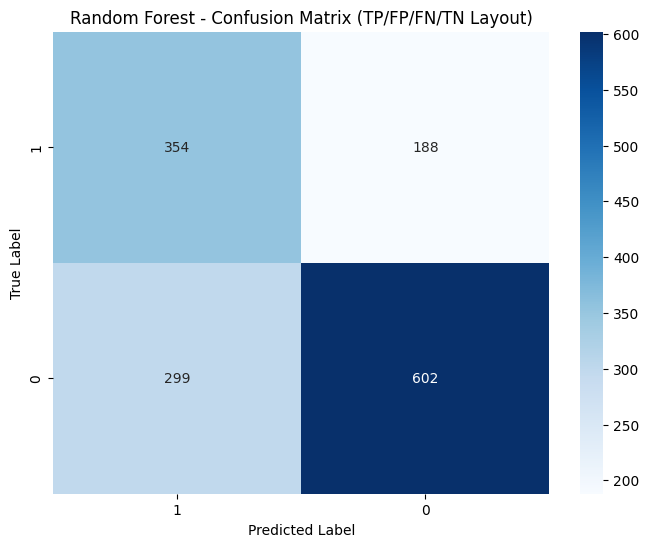

In [86]:
y_pred_A = model_A.predict(X_test)
accuracy_A = accuracy_score(y_test, y_pred_A)
print(f"Random Forest - Test Accuracy: {accuracy_A:.4f}")
cm_A = confusion_matrix(y_test, y_pred_A, labels=[0, 1])
print("Original confusion_matrix (TN, FP, FN, TP):\n", cm_A)
tn, fp, fn, tp = cm_A.ravel()
cm_display = np.array([[tp, fp],
                       [fn, tn]])
axis_labels_row = ['1', '0']
axis_labels_col = ['1', '0']
plt.figure(figsize=(8, 6)) # Set the figure size
sns.heatmap(cm_display, # Plot the REARRANGED matrix
            annot=True,        # Write the data value in each cell
            fmt="d",           # Format the annotations as integers
            cmap="Blues",      # Use the 'Blues' color map
            xticklabels=axis_labels_col, # Set labels for the x-axis reflecting the new order
            yticklabels=axis_labels_row)
plt.ylabel('True Label')     # Label for the y-axis
plt.xlabel('Predicted Label') # Label for the x-axis
plt.title('Random Forest - Confusion Matrix (TP/FP/FN/TN Layout)') # Plot title
plt.show()

Gradient Boost - Test Accuracy: 0.6812
Original confusion_matrix (TN, FP, FN, TP):
 [[614 176]
 [284 369]]


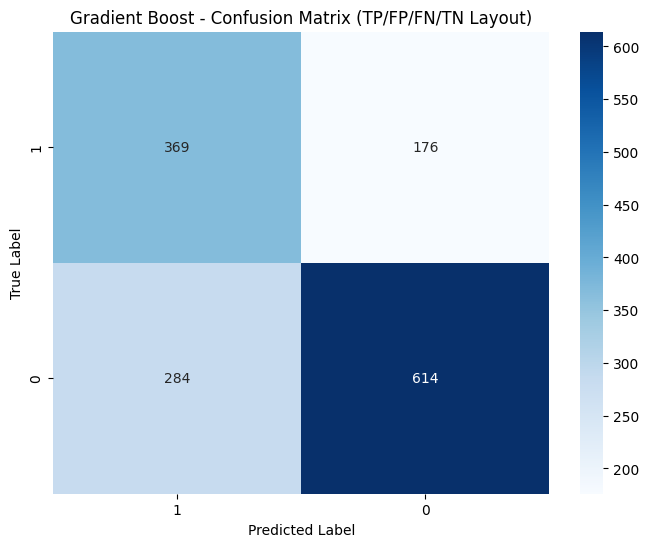

In [88]:
model_B = GradientBoostingClassifier(random_state=42)
model_B.fit(X_train, y_train)
y_pred_B = model_B.predict(X_test)
accuracy_B = accuracy_score(y_test, y_pred_B)
print(f"Gradient Boost - Test Accuracy: {accuracy_B:.4f}")
cm_B = confusion_matrix(y_test, y_pred_B, labels=[0, 1])
print("Original confusion_matrix (TN, FP, FN, TP):\n", cm_B)
tn, fp, fn, tp = cm_B.ravel()
cm_display = np.array([[tp, fp],
                       [fn, tn]])
axis_labels_row = ['1', '0']
axis_labels_col = ['1', '0']
plt.figure(figsize=(8, 6)) # Set the figure size
sns.heatmap(cm_display, # Plot the REARRANGED matrix
            annot=True,        # Write the data value in each cell
            fmt="d",           # Format the annotations as integers
            cmap="Blues",      # Use the 'Blues' color map
            xticklabels=axis_labels_col, # Set labels for the x-axis reflecting the new order
            yticklabels=axis_labels_row)
plt.ylabel('True Label')     # Label for the y-axis
plt.xlabel('Predicted Label') # Label for the x-axis
plt.title('Gradient Boost - Confusion Matrix (TP/FP/FN/TN Layout)') # Plot title
plt.show()